In [44]:
print("PBMRS notebook running successfully")

PBMRS notebook running successfully


In [45]:
import sys
import yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import scipy.stats as stats
from pathlib import Path

sys.path.append('../src')

from pbmrs_core.sim        import SimConfig, run_sim
from pbmrs_core.diagnostics  import drawdown, max_drawdown, recovery_time

print("Imports OK")


Imports OK


In [46]:
cfg_path = Path('../configs/base.yaml')
cfg_dict = yaml.safe_load(cfg_path.read_text())
cfg      = SimConfig(**cfg_dict)

print(f"seed={cfg.seed}  n_agents={cfg.n_agents}  timesteps={cfg.timesteps}")
print(f"J={cfg.J}  beta={cfg.beta}  J*beta={cfg.J * cfg.beta:.2f}  "
      f"({'subcritical' if cfg.J * cfg.beta < 1 else 'SUPERCRITICAL'})")
print(f"lam={cfg.lam}  sigma_eps={cfg.sigma_eps}  theta_v={cfg.theta_v}")


TypeError: SimConfig.__init__() got an unexpected keyword argument 'J'

In [ ]:
out = run_sim(cfg)
check_invariants(out, cfg)

print({k: out[k].shape for k in out})

{'x': (2001,),
 'r': (2001,),
 'v': (2001,),
 'l': (2001,),
 'm': (2001,),
 'Q': (2001,),
 'h': (2001,)}

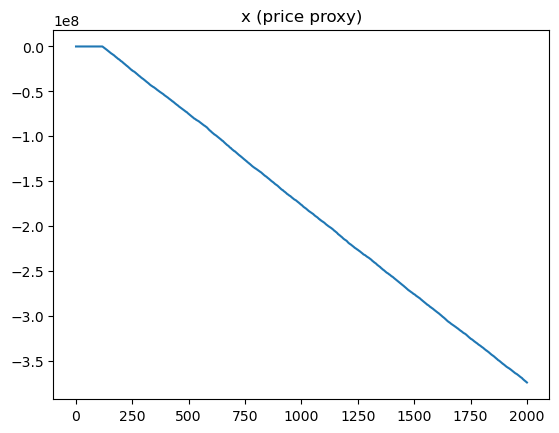

In [ ]:
T    = cfg.timesteps
time = np.arange(T + 1)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
fig.suptitle('PBMRS — Single Run: State Variables', fontsize=13, fontweight='bold')

axes[0].plot(time, out['x'], lw=0.8, color='steelblue')
axes[0].axhline(0, color='grey', lw=0.5, ls='--')
axes[0].set_ylabel('Log-price  $x_t$')

axes[1].plot(time, out['v'], lw=0.8, color='darkorange')
axes[1].axhline(cfg.theta_v, color='grey', lw=0.8, ls='--',
                label=f'θv = {cfg.theta_v}')
axes[1].set_ylabel('Volatility  $v_t$')
axes[1].legend(fontsize=8)

axes[2].plot(time, out['l'], lw=0.8, color='seagreen')
axes[2].axhline(cfg.l0, color='grey', lw=0.8, ls='--',
                label=f'ℓ₀ = {cfg.l0}')
axes[2].set_ylabel('Liquidity  $\\ell_t$')
axes[2].legend(fontsize=8)

axes[3].plot(time, out['m'], lw=0.8, color='crimson')
axes[3].axhline(0, color='grey', lw=0.5, ls='--')
axes[3].set_ylabel('Magnetization  $m_t$')
axes[3].set_xlabel('Time step')

plt.tight_layout()
plt.show()

print(f"Return std : {out['r'].std():.5f}")
print(f"Mean |m|   : {np.abs(out['m']).mean():.4f}")
print(f"Mean v     : {out['v'].mean():.5f}")
print(f"Mean l     : {out['l'].mean():.5f}")

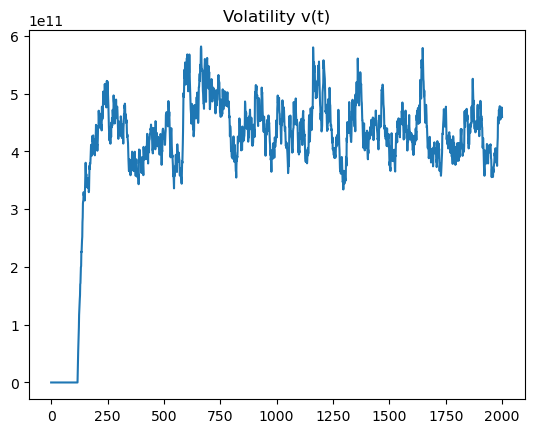

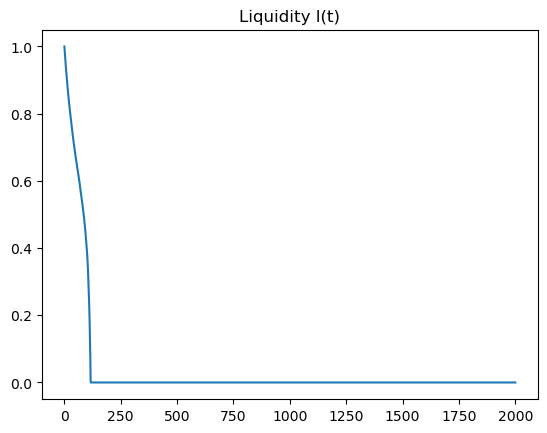

In [ ]:
r = out['r']

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle('Return Distribution', fontsize=12, fontweight='bold')

axes[0].hist(r, bins=60, density=True, alpha=0.6,
             color='steelblue', label='Simulated')
xs = np.linspace(r.min(), r.max(), 200)
axes[0].plot(xs, stats.norm.pdf(xs, r.mean(), r.std()),
             'r--', lw=1.5, label='Normal fit')
axes[0].set_xlabel('Return $r_t$')
axes[0].set_ylabel('Density')
axes[0].legend()

stats.probplot(r, dist='norm', plot=axes[1])
axes[1].set_title('QQ Plot vs Normal')

plt.tight_layout()
plt.show()

kurt = float(stats.kurtosis(r))
print(f"Excess kurtosis: {kurt:.3f}  ({'fat tails' if kurt > 0 else 'thin tails'})")

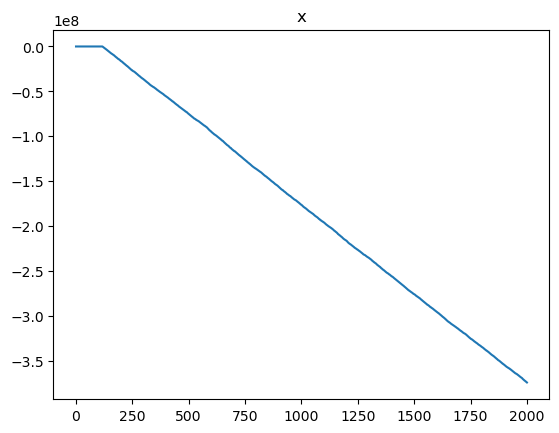

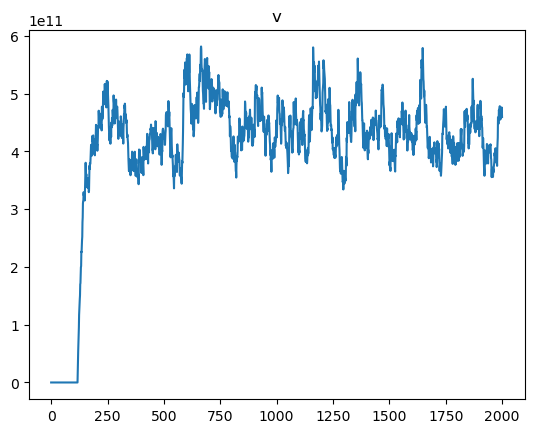

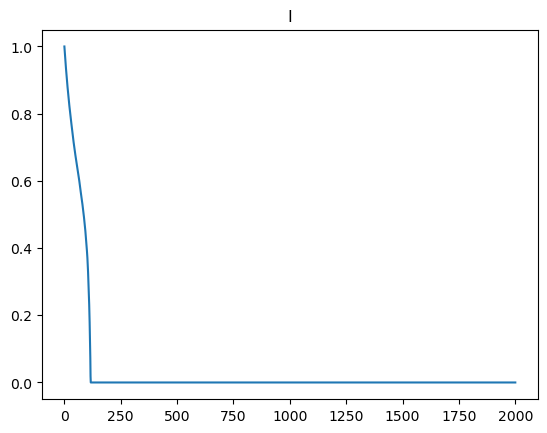

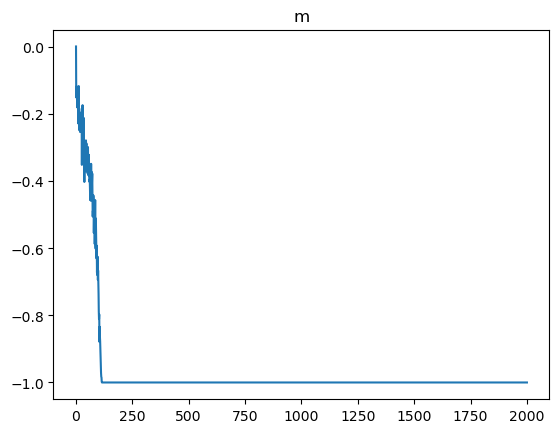

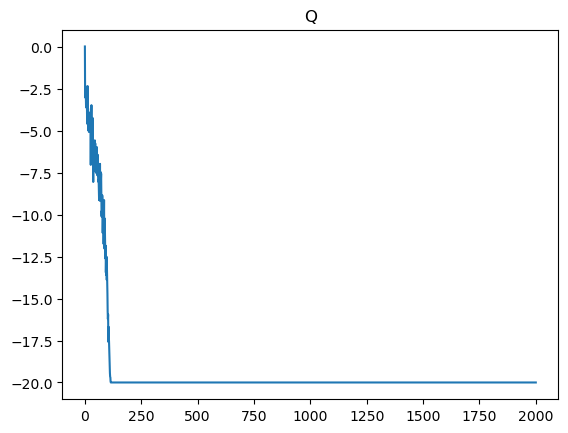

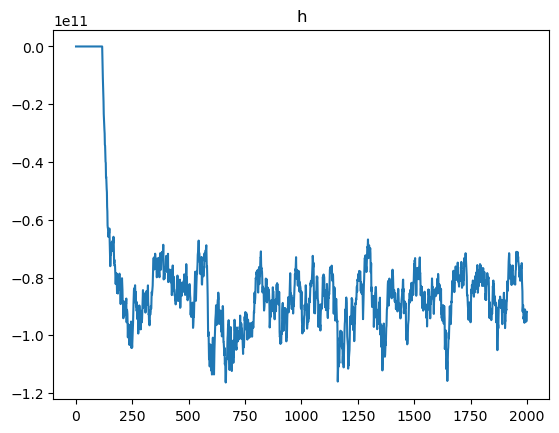

In [ ]:
# ── CELL 6: Drawdown ──────────────────────────────────────────────────────────
# Spec Eq.7: DD(t) = 1 - St/Mt  where St = exp(xt)
# Must pass price-space array, not log-price.

prices = np.exp(out['x'])
dd     = drawdown(prices)
mdd    = max_drawdown(prices)
rec    = recovery_time(prices)

print(f"Max drawdown  : {mdd:.4f}  ({mdd * 100:.1f}%)")
if rec is not None:
    print(f"Recovery time : {rec} steps")
else:
    print("Recovery time : did not recover within simulation window")


In [ ]:
# ── CELL 7: Drawdown plot ─────────────────────────────────────────────────────

peak = np.maximum.accumulate(prices)

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Drawdown Analysis', fontsize=12, fontweight='bold')

axes[0].plot(time, prices, lw=0.8, color='steelblue', label='Price $S_t$')
axes[0].plot(time, peak,   lw=1.0, color='grey', ls='--', label='Running peak $M_t$')
axes[0].set_ylabel('Price  $S_t$')
axes[0].legend(fontsize=8)

axes[1].fill_between(time, dd, alpha=0.4, color='crimson')
axes[1].plot(time, dd, lw=0.6, color='crimson')
axes[1].axhline(mdd, color='darkred', lw=1.0, ls='--',
                label=f'Max DD = {mdd:.3f}')
axes[1].set_ylabel('Drawdown  DD(t)')
axes[1].set_xlabel('Time step')
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

c:\Users\Mghou\OneDrive\Desktop\PBMRS\Public Repo\notebooks\../src\pbmrs_core\sim.py
['x', 'r', 'v', 'l', 'm', 'Q', 'h']


In [ ]:
# ── CELL 8: Fragility index ───────────────────────────────────────────────────
# README Eq.9: F(t) = wm*|mt| + wl*(l0/lt) + wv*(vt/theta_v)

wm, wl, wv = 1.0, 1.0, 1.0

F = (wm * np.abs(out['m'])
   + wl * (cfg.l0 / out['l'])
   + wv * (out['v'] / cfg.theta_v))

p33    = np.percentile(F, 33)
p66    = np.percentile(F, 66)
regime = np.where(F < p33, 0, np.where(F < p66, 1, 2))
# 0 = Stable,  1 = Fragile,  2 = Unstable

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
fig.suptitle('Fragility Index & Regime Labels', fontsize=12, fontweight='bold')

axes[0].plot(time, F, lw=0.8, color='purple')
axes[0].axhline(p33, color='green',  lw=0.8, ls='--', alpha=0.8,
                label=f'p33 = {p33:.2f}  (stable → fragile)')
axes[0].axhline(p66, color='orange', lw=0.8, ls='--', alpha=0.8,
                label=f'p66 = {p66:.2f}  (fragile → unstable)')
axes[0].set_ylabel('Fragility  F(t)')
axes[0].legend(fontsize=8)

color_map = {0: 'green', 1: 'orange', 2: 'red'}
label_map = {0: 'Stable', 1: 'Fragile', 2: 'Unstable'}
for r_id in [0, 1, 2]:
    mask = regime == r_id
    axes[1].scatter(time[mask], out['x'][mask],
                    s=1, c=color_map[r_id], label=label_map[r_id])
axes[1].set_ylabel('Log-price coloured by regime')
axes[1].set_xlabel('Time step')
axes[1].legend(fontsize=8, markerscale=5)

plt.tight_layout()
plt.show()

counts = {label_map[k]: int((regime == k).sum()) for k in range(3)}
print("Regime distribution:", counts)


# ── CELL 9: J sweep — run simulations ─────────────────────────────────────────
# Vary J (herding strength) while keeping beta fixed.
# Subcritical  J*beta < 1  → agents explore, no spontaneous herding
# Near-critical J*beta → 1 → strong herding, liquidity stress, high drawdowns
# Supercritical J*beta > 1 → agents lock to m=±1, system collapses

J_values = [0.3, 0.5, 0.7, 0.82]
palette  = ['steelblue', 'seagreen', 'darkorange', 'crimson']
results  = {}

for J_val in J_values:
    cfg_j          = SimConfig(**{**cfg_dict, 'J': J_val, 'seed': 42})
    results[J_val] = run_sim(cfg_j)
    r              = results[J_val]
    print(f"J={J_val:.2f}  J*beta={J_val * cfg.beta:.2f}  "
          f"max|m|={np.abs(r['m']).max():.3f}  "
          f"mean_v={r['v'].mean():.5f}  "
          f"min_l={r['l'].min():.4f}")

In [ ]:
# ── CELL 10: J sweep — state variable plots ───────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(12, 9), sharex=True)
fig.suptitle('Subcritical vs Near-Critical: J × β sweep',
             fontsize=12, fontweight='bold')

for J_val, colour in zip(J_values, palette):
    r     = results[J_val]
    label = f"J={J_val}  (J·β={J_val * cfg.beta:.2f})"
    axes[0].plot(r['x'], lw=0.7, color=colour, label=label)
    axes[1].plot(r['v'], lw=0.7, color=colour)
    axes[2].plot(r['l'], lw=0.7, color=colour)

axes[0].set_ylabel('Log-price  $x_t$')
axes[0].legend(fontsize=8, loc='upper left')

axes[1].set_ylabel('Volatility  $v_t$')
axes[1].axhline(cfg.theta_v, color='grey', lw=0.8, ls='--',
                label=f'θv = {cfg.theta_v}')
axes[1].legend(fontsize=8)

axes[2].set_ylabel('Liquidity  $\\ell_t$')
axes[2].axhline(cfg.l0, color='grey', lw=0.8, ls='--',
                label=f'ℓ₀ = {cfg.l0}')
axes[2].set_xlabel('Time step')
axes[2].legend(fontsize=8)

plt.tight_layout()
plt.show()


In [ ]:
# ── CELL 11: J sweep — magnetization histograms ───────────────────────────────

fig, axes = plt.subplots(1, len(J_values), figsize=(14, 3), sharey=True)
fig.suptitle('Magnetization Distribution by J', fontsize=11, fontweight='bold')

for ax, (J_val, colour) in zip(axes, zip(J_values, palette)):
    m = results[J_val]['m']
    ax.hist(m, bins=40, density=True, color=colour, alpha=0.7)
    ax.axvline(0, color='grey', lw=0.8, ls='--')
    ax.set_title(f"J={J_val}  (J·β={J_val * cfg.beta:.2f})")
    ax.set_xlabel('$m_t$')
axes[0].set_ylabel('Density')

plt.tight_layout()
plt.show()

In [ ]:
# ── CELL 12: J sweep — summary statistics table ───────────────────────────────

print(f"\n{'J':>5}  {'J*β':>5}  {'RetStd':>8}  {'MDD':>7}  {'MeanV':>8}  {'MinL':>7}")
print('-' * 50)
for J_val in J_values:
    r    = results[J_val]
    px   = np.exp(r['x'])
    mdd  = max_drawdown(px)
    print(f"{J_val:>5.2f}  {J_val * cfg.beta:>5.2f}  "
          f"{r['r'].std():>8.5f}  {mdd:>7.4f}  "
          f"{r['v'].mean():>8.5f}  {r['l'].min():>7.4f}")


